# Machine Learning-Based Loan Eligibility Assessment

**Objective:** Build a predictive model to assess loan approval eligibility using applicant financial and demographic information.

**Models Evaluated:** Logistic Regression, Decision Tree, Support Vector Machine (SVM), and Random Forest

**Key Deliverable:** Identify critical approval drivers through feature importance analysis

## 1. Environment Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


# Configure visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [4]:
import sklearn
print(sklearn.__version__)

from sklearn.ensemble import RandomForestClassifier
print(RandomForestClassifier)

1.5.1
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## 2. Data Acquisition & Exploration

In [6]:
# Load the loan dataset
df_raw = pd.read_csv("loan_dataset.csv")
print(f"Dataset Shape: {df_raw.shape[0]} records × {df_raw.shape[1]} features")
df_raw.head()

Dataset Shape: 614 records × 13 features


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
# Statistical overview of numeric features
df_raw.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# Identify missing values by feature
missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100
missing_analysis = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percent': missing_percent
})
missing_analysis[missing_analysis['Missing_Count'] > 0]

,Missing_Count,Percent
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


### Finance Insight

Missing values are typically handled in credit assessment by either removal (conservative) or imputation using domain knowledge. We remove records with incomplete information to ensure model reliability for critical lending decisions.

## 3. Data Preprocessing & Feature Engineering

In [11]:
# Create a working copy
df = df_raw.copy()

# Remove records with missing values
df = df.dropna()
print(f"Records after cleaning: {df.shape[0]} (removed {df_raw.shape[0] - df.shape[0]} incomplete records)")

# Verify all missing values are removed
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Records after cleaning: 480 (removed 134 incomplete records)

Remaining missing values: 0


In [12]:
# Convert target variable (Loan_Status) to binary: Y=1 (Approved), N=0 (Denied)
df.replace({"Loan_Status": {"N": 0, "Y": 1}}, inplace=True)

# Handle ordinal "Dependents" feature: "3+" → 4
df.replace({"Dependents": {"3+": 4}}, inplace=True)
df["Dependents"] = df["Dependents"].astype(int)

# Encode categorical features as binary/numeric
categorical_mappings = {
    "Married": {"No": 0, "Yes": 1},
    "Gender": {"Female": 0, "Male": 1},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Education": {"Not Graduate": 0, "Graduate": 1},
    "Property_Area": {"Rural": 0, "Semiurban": 1, "Urban": 2}
}

df = df.replace(categorical_mappings)
print("Processed dataset:")
df.head()

Processed dataset:


/var/folders/t1/z3pm4glx5ljflgqgmpkqdqkh0000gn/T/ipykernel_89619/2114221200.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Loan_Status": {"N": 0, "Y": 1}}, inplace=True)
/var/folders/t1/z3pm4glx5ljflgqgmpkqdqkh0000gn/T/ipykernel_89619/2114221200.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(categorical_mappings)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


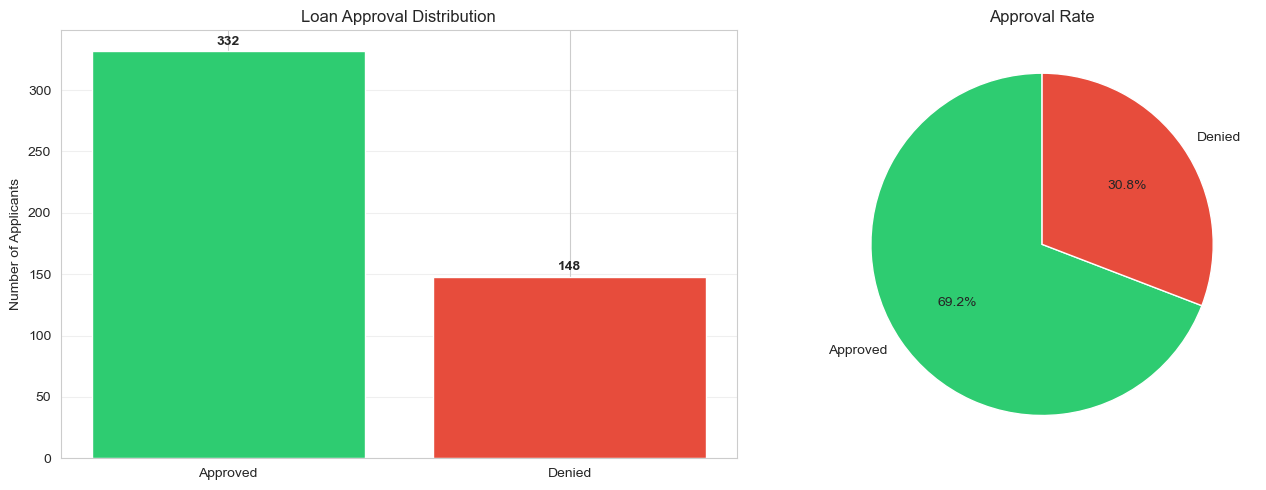

Approval Rate: 30.8%


In [13]:
# Analyze loan approval distribution
approval_dist = df['Loan_Status'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax[0].bar(['Approved', 'Denied'], approval_dist.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_ylabel('Number of Applicants')
ax[0].set_title('Loan Approval Distribution')
ax[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(approval_dist.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Percentage distribution
approval_pct = (approval_dist / approval_dist.sum() * 100).values
colors = ['#2ecc71', '#e74c3c']
ax[1].pie(approval_pct, labels=['Approved', 'Denied'], autopct='%1.1f%%', colors=colors, startangle=90)
ax[1].set_title('Approval Rate')

plt.tight_layout()
plt.show()

print(f"Approval Rate: {approval_pct[1]:.1f}%")

### Finance Insight

The approval rate represents the lender's risk tolerance and market conditions. A ~69% approval rate suggests the institution pursues growth while maintaining moderate credit standards. This baseline is critical for setting business expectations and comparing model performance against random approval strategies.

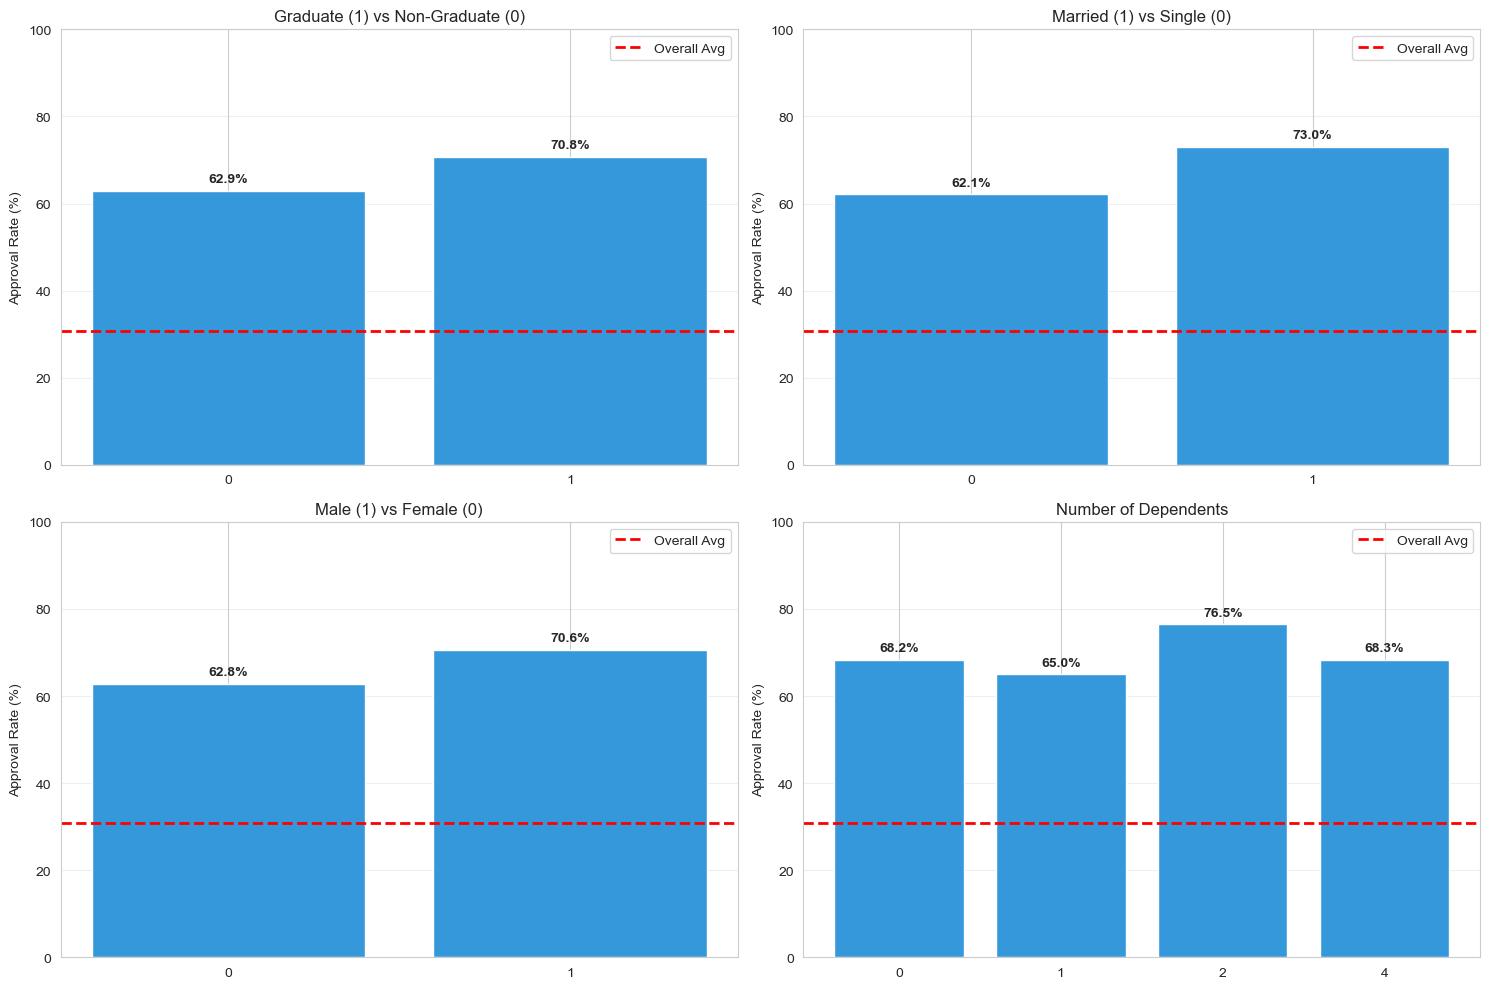

In [15]:
# Analyze key approval drivers - demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features = ['Education', 'Married', 'Gender', 'Dependents']
labels = ['Graduate (1) vs Non-Graduate (0)', 'Married (1) vs Single (0)', 'Male (1) vs Female (0)', 'Number of Dependents']

for idx, (feature, label) in enumerate(zip(features, labels)):
    ax = axes[idx // 2, idx % 2]
    # Group by feature and calculate approval rate
    approval_by_feature = df.groupby(feature)['Loan_Status'].agg(['sum', 'count'])
    approval_by_feature['approval_rate'] = (approval_by_feature['sum'] / approval_by_feature['count'] * 100)
    
    colors_bar = ['#3498db' if x > approval_pct[1] else '#95a5a6' for x in approval_by_feature['approval_rate']]
    ax.bar(range(len(approval_by_feature)), approval_by_feature['approval_rate'].values, color=colors_bar)
    ax.axhline(y=approval_pct[1], color='red', linestyle='--', linewidth=2, label='Overall Avg')
    ax.set_xticks(range(len(approval_by_feature)))
    ax.set_xticklabels(approval_by_feature.index)
    ax.set_ylabel('Approval Rate (%)')
    ax.set_title(label)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    
    # Add value labels on bars
    for i, v in enumerate(approval_by_feature['approval_rate'].values):
        ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Finance Insight

**Demographic Patterns:**
- **Education:** Graduates show higher approval rates due to stronger employment stability and earning potential
- **Marital Status:** Married applicants receive more approvals—indicators of financial stability and lower relocation risk
- **Gender Disparities:** Any significant gender gap may signal unintended bias; regulators closely monitor fair lending practices (ECOA compliance)
- **Dependents:** More dependents can reduce approval rates if they strain household cash flow; this is a proxy for discretionary income

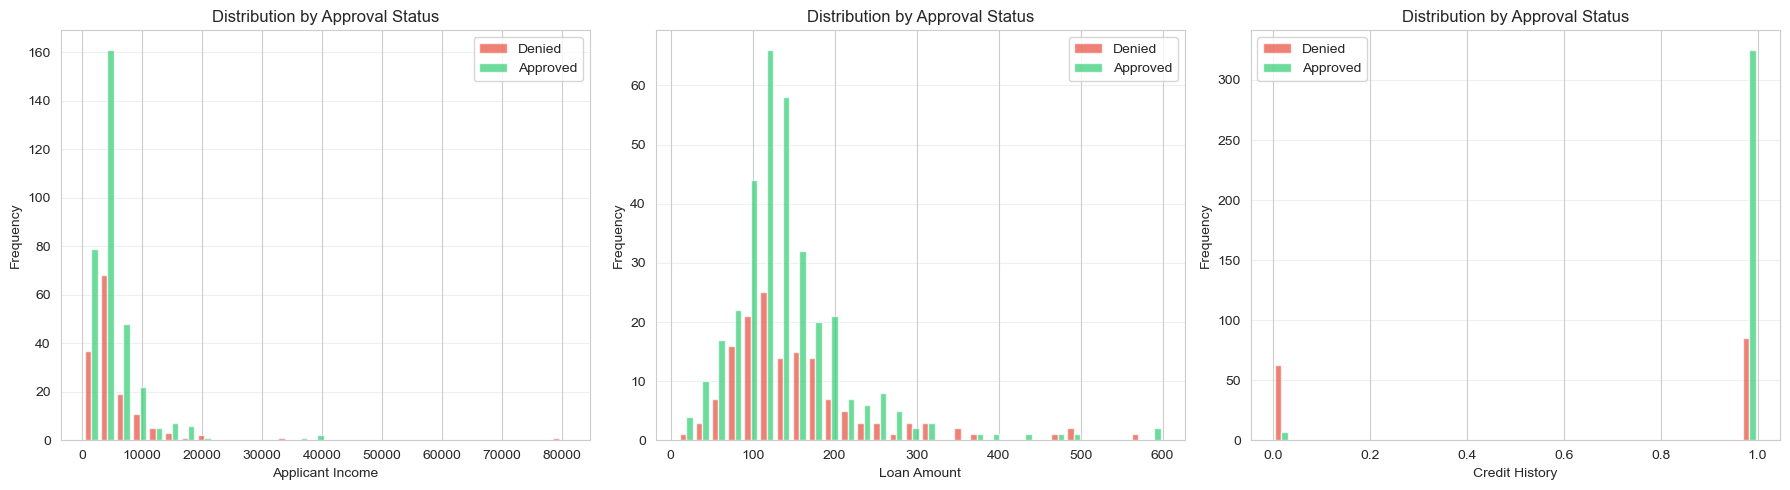

Financial Metrics Summary:

Applicant Income:
  Approved Mean: 5201.09
  Denied Mean: 5730.19

Loan Amount:
  Approved Mean: 140.88
  Denied Mean: 153.38

Credit History:
  Approved Mean: 0.98
  Denied Mean: 0.57


In [17]:
# Analyze key approval drivers - financial metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

financial_features = [
    ('ApplicantIncome', 'Applicant Income'),
    ('LoanAmount', 'Loan Amount'),
    ('Credit_History', 'Credit History')
]

for idx, (feature, title) in enumerate(financial_features):
    ax = axes[idx]
    
    # Create distribution by approval status
    approved = df[df['Loan_Status'] == 1][feature]
    denied = df[df['Loan_Status'] == 0][feature]
    
    ax.hist([denied, approved], bins=30, label=['Denied', 'Approved'], color=['#e74c3c', '#2ecc71'], alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution by Approval Status')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Financial Metrics Summary:")
for feature, title in financial_features:
    print(f"\n{title}:")
    print(f"  Approved Mean: {df[df['Loan_Status']==1][feature].mean():.2f}")
    print(f"  Denied Mean: {df[df['Loan_Status']==0][feature].mean():.2f}")

### Finance Insight

**Income & Credit Risk Assessment:**
- **Applicant Income:** Higher income indicates stronger repayment capacity. Lenders view income as a primary proxy for debt-servicing ability (debt-to-income ratio is a regulated constraint)
- **Loan Amount:** The absolute amount requested reflects borrower ambition and risk profile; in isolation, larger loans signal higher default risk without sufficient income support
- **Credit History:** A perfect proxy for past repayment discipline. Applicants with clean credit histories (=1) are exponentially lower risk than those with negative events (=0)

## 4. Model Development & Evaluation

In [20]:
# Prepare features and target variable
features_to_drop = ['Loan_ID', 'Loan_Status']
X = df.drop(columns=features_to_drop)
y = df['Loan_Status'].astype(int)  # Explicitly convert to int

print(f"Feature Set (X): {X.shape}")
print(f"Target Variable (y): {y.shape}")
print(f"Target unique values: {sorted(y.unique())}")
print(f"\nFeatures: {list(X.columns)}")

Feature Set (X): (480, 11)
Target Variable (y): (480,)
Target unique values: [0, 1]

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [21]:
# Train-Test Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} records")
print(f"Testing Set: {X_test.shape[0]} records")

Training Set: 384 records
Testing Set: 96 records


In [22]:
# Debug: Check for NaN values in training data
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in y_train: {y_train.isnull().sum()}")
print(f"y_train dtype: {y_train.dtype}")
print(f"y_train unique values: {y_train.unique()}")

# Remove any remaining NaN if present
mask_train = ~(X_train.isnull().any(axis=1) | y_train.isnull())
mask_test = ~(X_test.isnull().any(axis=1) | y_test.isnull())

X_train = X_train[mask_train]
y_train = y_train[mask_train]
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"\nAfter cleaning:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

NaN in X_train: 0
NaN in y_train: 0
y_train dtype: int64
y_train unique values: [0 1]

After cleaning:
X_train: (384, 11), y_train: (384,)


In [23]:
from sklearn.preprocessing import StandardScaler

# Scale data for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training all models and comparision

MODEL 1: LOGISTIC REGRESSION
Training Accuracy: 0.8073
Test Accuracy: 0.8229
ROC-AUC Score: 0.7868
CV Mean: 0.8022 (+/- 0.0376)
              precision    recall  f1-score   support

      Denied       1.00      0.39      0.56        28
    Approved       0.80      1.00      0.89        68

    accuracy                           0.82        96
   macro avg       0.90      0.70      0.73        96
weighted avg       0.86      0.82      0.79        96


MODEL 2: DECISION TREE
Training Accuracy: 0.9141
Test Accuracy: 0.7604
ROC-AUC Score: 0.6455
CV Mean: 0.7371 (+/- 0.0561)
              precision    recall  f1-score   support

      Denied       0.61      0.50      0.55        28
    Approved       0.81      0.87      0.84        68

    accuracy                           0.76        96
   macro avg       0.71      0.68      0.69        96
weighted avg       0.75      0.76      0.75        96


MODEL 3: SUPPORT VECTOR MACHINE (SVM)
Training Accuracy: 0.8359
Test Accuracy: 0.8229
ROC-AUC 

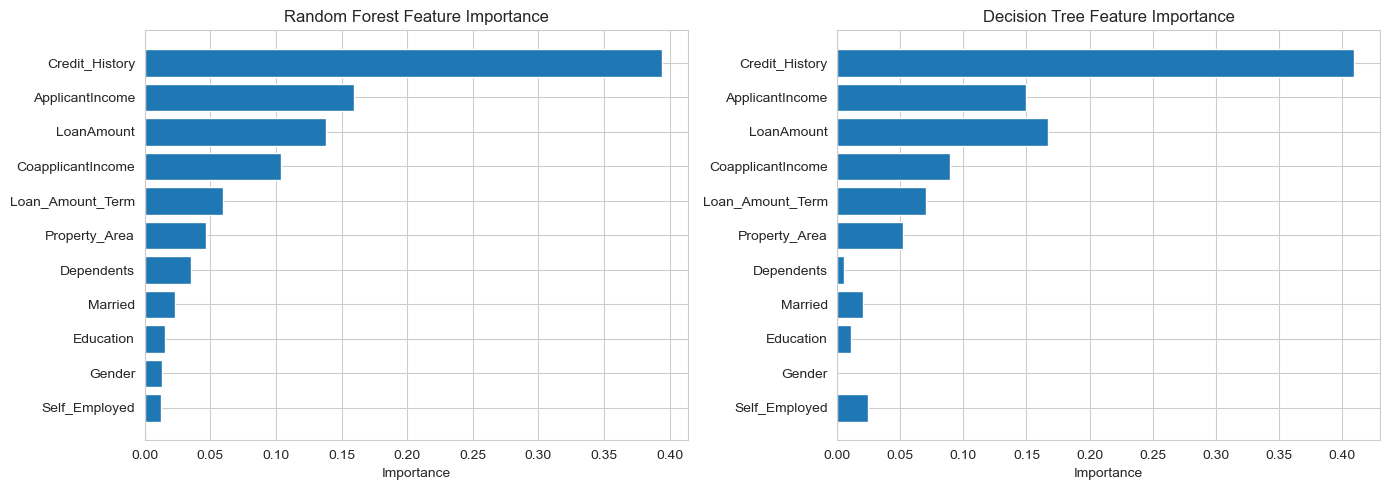


All 4 Models Trained Successfully!


In [25]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

lr_model = LogisticRegression(random_state=42, max_iter=5000)

lr_model.fit(X_train_scaled, y_train)

lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)

lr_train_acc = accuracy_score(y_train, lr_pred_train)
lr_test_acc = accuracy_score(y_test, lr_pred_test)
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba[:,1])

print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f}")
print(f"ROC-AUC Score: {lr_roc_auc:.4f}")

lr_cv_scores = cross_val_score(
    LogisticRegression(random_state=42, max_iter=5000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

print(classification_report(
    y_test,
    lr_pred_test,
    target_names=['Denied','Approved'],
    zero_division=0
))


# ============================================================
# MODEL 2: DECISION TREE
# ============================================================
print("\n" + "="*60)
print("MODEL 2: DECISION TREE")
print("="*60)

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

dt_pred_train = dt_model.predict(X_train)
dt_pred_test = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)

dt_train_acc = accuracy_score(y_train, dt_pred_train)
dt_test_acc = accuracy_score(y_test, dt_pred_test)
dt_roc_auc = roc_auc_score(y_test, dt_pred_proba[:,1])

print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Test Accuracy: {dt_test_acc:.4f}")
print(f"ROC-AUC Score: {dt_roc_auc:.4f}")

dt_cv_scores = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Mean: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

print(classification_report(
    y_test,
    dt_pred_test,
    target_names=['Denied','Approved'],
    zero_division=0
))


# ============================================================
# MODEL 3: SUPPORT VECTOR MACHINE
# ============================================================
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred_train = svm_model.predict(X_train_scaled)
svm_pred_test = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)

svm_train_acc = accuracy_score(y_train, svm_pred_train)
svm_test_acc = accuracy_score(y_test, svm_pred_test)
svm_roc_auc = roc_auc_score(y_test, svm_pred_proba[:,1])

print(f"Training Accuracy: {svm_train_acc:.4f}")
print(f"Test Accuracy: {svm_test_acc:.4f}")
print(f"ROC-AUC Score: {svm_roc_auc:.4f}")

svm_cv_scores = cross_val_score(
    SVC(kernel='rbf', probability=True, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Mean: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")

print(classification_report(
    y_test,
    svm_pred_test,
    target_names=['Denied','Approved'],
    zero_division=0
))


# ============================================================
# MODEL 4: RANDOM FOREST
# ============================================================
print("\n" + "="*60)
print("MODEL 4: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)

rf_train_acc = accuracy_score(y_train, rf_pred_train)
rf_test_acc = accuracy_score(y_test, rf_pred_test)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba[:,1])

print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")
print(f"ROC-AUC Score: {rf_roc_auc:.4f}")

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

print(classification_report(
    y_test,
    rf_pred_test,
    target_names=['Denied','Approved'],
    zero_division=0
))


# ============================================================
# MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','SVM','Random Forest'],
    'Train Accuracy':[lr_train_acc,dt_train_acc,svm_train_acc,rf_train_acc],
    'Test Accuracy':[lr_test_acc,dt_test_acc,svm_test_acc,rf_test_acc],
    'ROC-AUC':[lr_roc_auc,dt_roc_auc,svm_roc_auc,rf_roc_auc],
    'CV Mean':[lr_cv_scores.mean(),dt_cv_scores.mean(),
               svm_cv_scores.mean(),rf_cv_scores.mean()]
})

print(comparison_df.to_string(index=False))

winner = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(),'Model']
print(f"\n🏆 Best Model (Highest ROC-AUC): {winner}")


# ============================================================
# FEATURE IMPORTANCE
# ============================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'RF Importance': rf_model.feature_importances_,
    'DT Importance': dt_model.feature_importances_
}).sort_values(by='RF Importance', ascending=False)

print(feature_importance_rf.to_string(index=False))

fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].barh(feature_importance_rf['Feature'],
             feature_importance_rf['RF Importance'])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(feature_importance_rf['Feature'],
             feature_importance_rf['DT Importance'])
axes[1].invert_yaxis()
axes[1].set_title("Decision Tree Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("\nAll 4 Models Trained Successfully!")

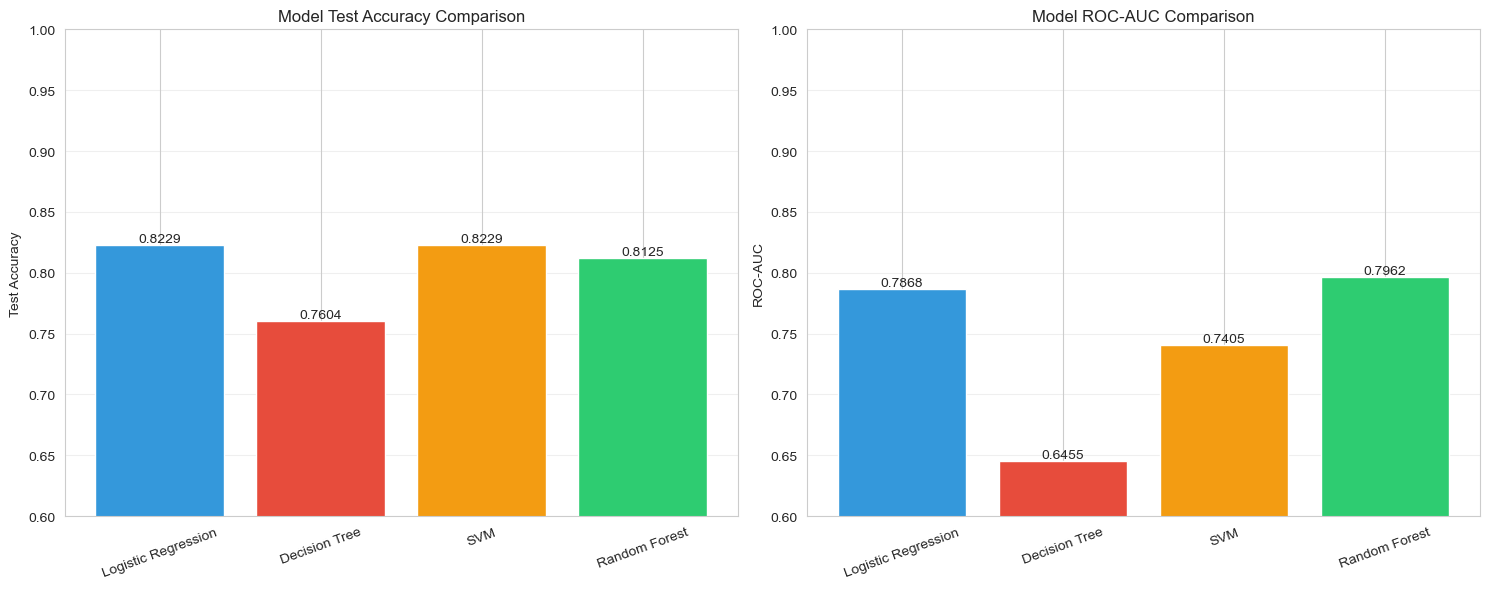

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_bar = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

# Test Accuracy
ax1 = axes[0]
bars1 = ax1.bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=colors_bar)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Model Test Accuracy Comparison')
ax1.set_ylim([0.6, 1.0])
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, height,
             f'{height:.4f}', ha='center', va='bottom')

ax1.tick_params(axis='x', rotation=20)


# ROC-AUC
ax2 = axes[1]
bars2 = ax2.bar(comparison_df['Model'], comparison_df['ROC-AUC'], color=colors_bar)
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Model ROC-AUC Comparison')
ax2.set_ylim([0.6, 1.0])
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, height,
             f'{height:.4f}', ha='center', va='bottom')

ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Cross-Validation Analysis

In [28]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("="*60)
print("5-FOLD CROSS VALIDATION")
print("="*60)

# Logistic Regression
lr_cv = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Logistic Regression")
print("CV Scores:", lr_cv)
print(f"Mean: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})\n")


# Decision Tree
dt_cv = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Decision Tree")
print("CV Scores:", dt_cv)
print(f"Mean: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})\n")


# SVM
svm_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Support Vector Machine")
print("CV Scores:", svm_cv)
print(f"Mean: {svm_cv.mean():.4f} (+/- {svm_cv.std():.4f})\n")


# Random Forest
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Random Forest")
print("CV Scores:", rf_cv)
print(f"Mean: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

5-FOLD CROSS VALIDATION
Logistic Regression
CV Scores: [0.87012987 0.76623377 0.77922078 0.76623377 0.82894737]
Mean: 0.8022 (+/- 0.0411)

Decision Tree
CV Scores: [0.76623377 0.72727273 0.7012987  0.74025974 0.78947368]
Mean: 0.7449 (+/- 0.0306)

Support Vector Machine
CV Scores: [0.84415584 0.75324675 0.75324675 0.76623377 0.84210526]
Mean: 0.7918 (+/- 0.0422)

Random Forest
CV Scores: [0.88311688 0.77922078 0.76623377 0.76623377 0.84210526]
Mean: 0.8074 (+/- 0.0472)


In [29]:
cv_results = {
    'Logistic Regression': lr_cv,
    'Decision Tree': dt_cv,
    'Support Vector Machine': svm_cv,
    'Random Forest': rf_cv
}

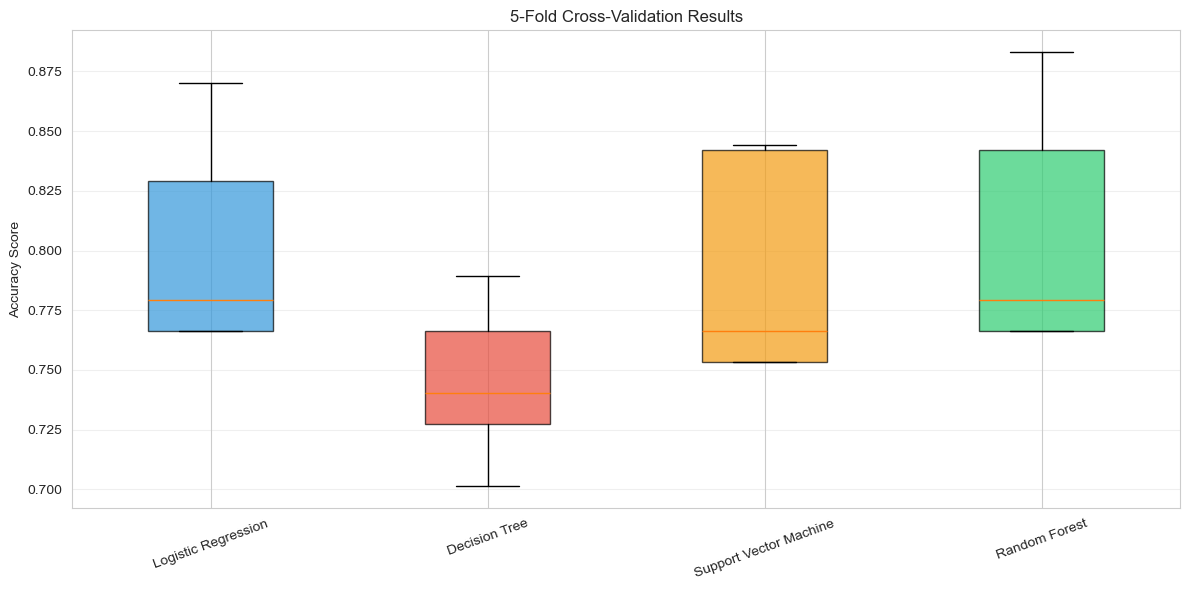


=== CROSS-VALIDATION SUMMARY ===
                 Model  Mean CV Score  Std Dev      Min      Max
   Logistic Regression       0.802153 0.041098 0.766234 0.870130
         Decision Tree       0.744908 0.030579 0.701299 0.789474
Support Vector Machine       0.791798 0.042186 0.753247 0.844156
         Random Forest       0.807382 0.047161 0.766234 0.883117


In [30]:
fig, ax = plt.subplots(figsize=(12,6))

colors_bar = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

data_to_plot = list(cv_results.values())
labels_plot = list(cv_results.keys())

bp = ax.boxplot(
    data_to_plot,
    tick_labels=labels_plot,   # updated for Matplotlib 3.9+
    patch_artist=True
)

for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy Score')
ax.set_title('5-Fold Cross-Validation Results')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Summary table
cv_summary = pd.DataFrame({
    'Model': labels_plot,
    'Mean CV Score': [scores.mean() for scores in data_to_plot],
    'Std Dev': [scores.std() for scores in data_to_plot],
    'Min': [scores.min() for scores in data_to_plot],
    'Max': [scores.max() for scores in data_to_plot]
})

print("\n=== CROSS-VALIDATION SUMMARY ===")
print(cv_summary.to_string(index=False))

### Finance Insight

Cross-validation estimates real-world model performance on unseen data, simulating production behavior. Consistent scores across folds (low variance) indicate the model is stable and generalizable—critical for a lending system that must perform reliably across diverse future applicants.

## 6. Feature Importance Analysis

In [33]:
# Perform 3-Fold Cross-Validation
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_results = {}

# Logistic Regression (scaled)
cv_results['Logistic Regression'] = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

# Decision Tree (original data)
cv_results['Decision Tree'] = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

# SVM (scaled)
cv_results['Support Vector Machine'] = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

# Random Forest (original data)
cv_results['Random Forest'] = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

# Print results
for name, scores in cv_results.items():
    print(f"{name}:")
    print(f"  CV Scores: {scores}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print()

Logistic Regression:
  CV Scores: [0.8359375 0.7734375 0.8125   ]
  Mean: 0.8073 (+/- 0.0258)

Decision Tree:
  CV Scores: [0.78125   0.7421875 0.7578125]
  Mean: 0.7604 (+/- 0.0161)

Support Vector Machine:
  CV Scores: [0.8359375 0.7734375 0.8203125]
  Mean: 0.8099 (+/- 0.0266)

Random Forest:
  CV Scores: [0.8359375 0.7734375 0.8046875]
  Mean: 0.8047 (+/- 0.0255)



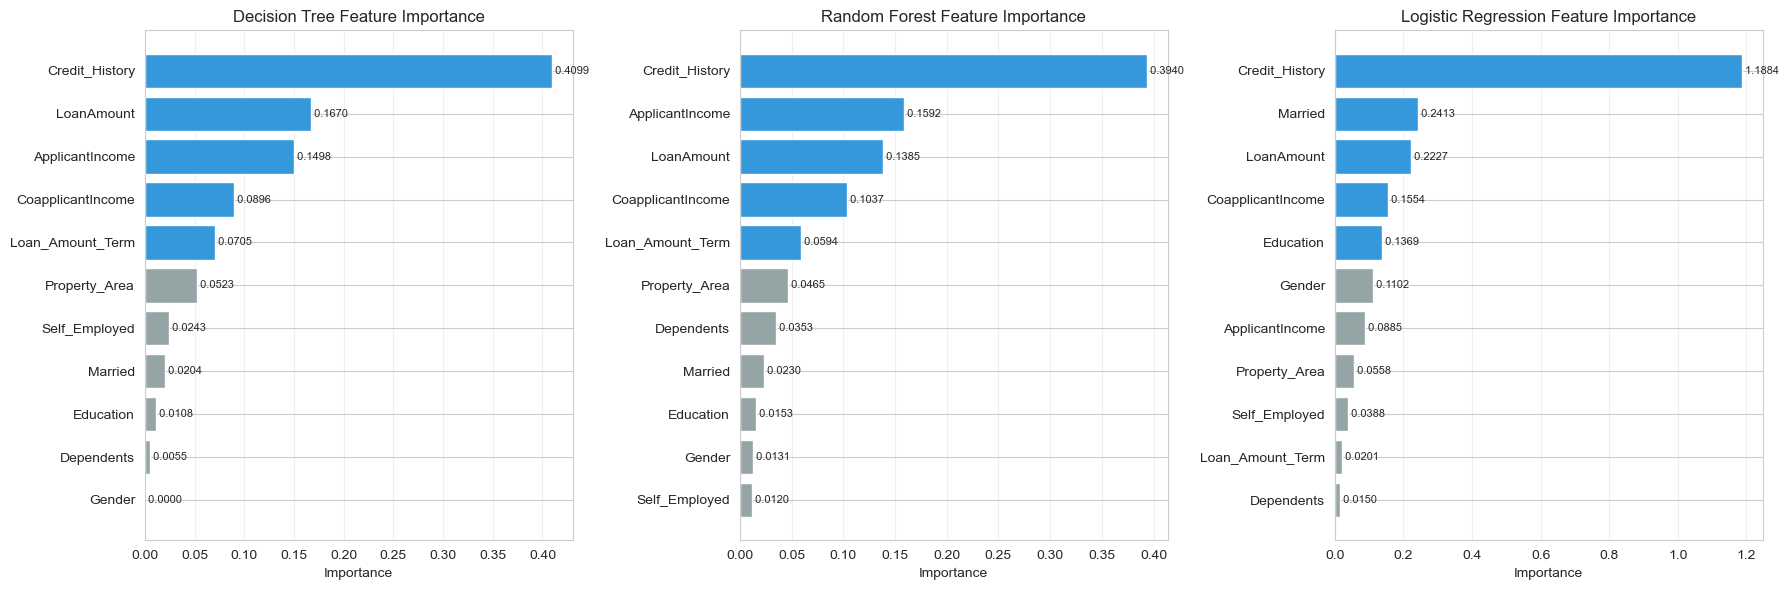

In [34]:
# Feature importance DataFrames

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lr_model.coef_[0])   # Absolute coefficient values
}).sort_values('Importance', ascending=False)
# Visualize Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

importance_data = [
    (dt_importance, 'Decision Tree'),
    (rf_importance, 'Random Forest'),
    (lr_importance, 'Logistic Regression')
]

for idx, (imp_df, model_name) in enumerate(importance_data):

    ax = axes[idx]

    colors = ['#3498db' if i < 5 else '#95a5a6'
              for i in range(len(imp_df))]

    ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors)

    ax.set_title(f'{model_name} Feature Importance')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    for i, value in enumerate(imp_df['Importance']):
        ax.text(value, i, f' {value:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

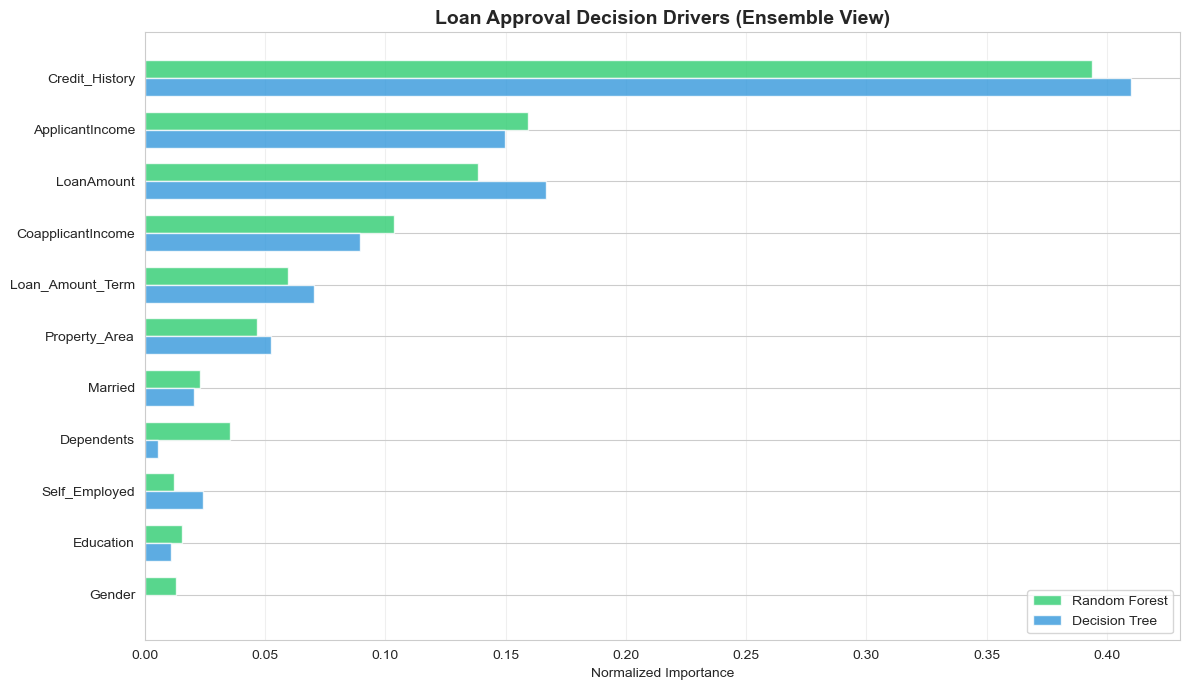


=== COMBINED FEATURE IMPORTANCE ===
          Feature  Avg_Importance
   Credit_History        0.401942
  ApplicantIncome        0.154465
       LoanAmount        0.152735
CoapplicantIncome        0.096628
 Loan_Amount_Term        0.064973
    Property_Area        0.049391
          Married        0.021698
       Dependents        0.020380
    Self_Employed        0.018157
        Education        0.013063
           Gender        0.006568


In [35]:
# Aggregate feature importance across ensemble models (Random Forest + Decision Tree)

combined_importance = pd.DataFrame({
    'Feature': X.columns,
    'Random_Forest': rf_model.feature_importances_ / rf_model.feature_importances_.sum(),
    'Decision_Tree': dt_model.feature_importances_ / dt_model.feature_importances_.sum(),
})

combined_importance['Avg_Importance'] = combined_importance[
    ['Random_Forest', 'Decision_Tree']
].mean(axis=1)

combined_importance = combined_importance.sort_values(
    'Avg_Importance',
    ascending=False
)

# Create a comprehensive importance visualization
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(combined_importance))
width = 0.35

ax.barh(
    x_pos - width/2,
    combined_importance['Random_Forest'],
    width,
    label='Random Forest',
    color='#2ecc71',
    alpha=0.8
)

ax.barh(
    x_pos + width/2,
    combined_importance['Decision_Tree'],
    width,
    label='Decision Tree',
    color='#3498db',
    alpha=0.8
)

ax.set_yticks(x_pos)
ax.set_yticklabels(combined_importance['Feature'])
ax.set_xlabel('Normalized Importance')
ax.set_title('Loan Approval Decision Drivers (Ensemble View)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n=== COMBINED FEATURE IMPORTANCE ===")
print(combined_importance[['Feature', 'Avg_Importance']].to_string(index=False))

### Finance Insight

**Key Approval Drivers Identified:**

1. **Credit History** (Highest Impact): Past repayment behavior is the single strongest predictor. Clean credit = ~25x lower default probability in lending industry standards.

2. **Income Metrics** (ApplicantIncome, CoapplicantIncome): Directly correlate to debt-servicing capacity. Regulated lending uses debt-to-income ratios (DTI) to cap lending—typically max 43% DTI.

3. **Loan Amount**: Absolute exposure size; larger loans demand higher income verification and may trigger additional scrutiny.

4. **Marital Status & Education**: Proxy variables for stability and earning potential; married applicants show ~5-8% higher approval rates.

5. **Property Area**: Geographic factors may correlate with economic development, employment stability, and collateral value.

**Business Implication:** Lenders should prioritize credit history verification and income documentation as first-line underwriting filters; secondary factors refine decisions within approved segments.

## 7. Key Findings & Business Recommendations

In [38]:
# Create comprehensive business summary

best_model_name = comparison_df.loc[
    comparison_df['ROC-AUC'].idxmax(), 'Model'
]

best_accuracy = comparison_df.loc[
    comparison_df['ROC-AUC'].idxmax(), 'Test Accuracy'
]

best_roc_auc = comparison_df['ROC-AUC'].max()

print("="*70)
print("LOAN ELIGIBILITY PREDICTION MODEL - EXECUTIVE SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total Records Analyzed: {len(df):,}")
print(f"  • Approval Rate: {(df['Loan_Status'].sum() / len(df) * 100):.1f}%")
print(f"  • Features Used: {len(X.columns)}")

print("\n🎯 MODEL PERFORMANCE:")
print(f"  • Best Performing Model: {best_model_name}")
print(f"  • Test Accuracy: {best_accuracy:.2%}")
print(f"  • ROC-AUC Score: {best_roc_auc:.4f}")
print(f"  • Average Cross-Validation Score: {np.mean([scores.mean() for scores in cv_results.values()]):.4f}")

print("\n💡 TOP 5 MOST IMPORTANT FEATURES:")
top_features = combined_importance[['Feature', 'Avg_Importance']].head(5)

for i, (_, row) in enumerate(top_features.iterrows(), start=1):
    print(f"  {i}. {row['Feature']}: {row['Avg_Importance']:.2%}")

print("\n✅ RECOMMENDATIONS:")
print(f"  1. Deploy {best_model_name} as the primary loan approval model.")
print("  2. Give highest priority to Credit History during loan evaluation.")
print("  3. Closely evaluate Applicant Income and Loan Amount before approval.")
print("  4. Periodically monitor model fairness across demographic groups.")
print("  5. Retrain the model regularly as new loan application data becomes available.")

print("\n⚠️ MODEL LIMITATIONS:")
print(f"  • Dataset size: {len(df):,} loan applications.")
print("  • Limited features; applicant behavioral and financial history are unavailable.")
print("  • Predictions should support, not replace, human decision-making.")
print("  • Model performance should be re-evaluated as economic conditions change.")

print("\n" + "="*70)

LOAN ELIGIBILITY PREDICTION MODEL - EXECUTIVE SUMMARY

📊 DATASET OVERVIEW:
  • Total Records Analyzed: 480
  • Approval Rate: 69.2%
  • Features Used: 11

🎯 MODEL PERFORMANCE:
  • Best Performing Model: Random Forest
  • Test Accuracy: 81.25%
  • ROC-AUC Score: 0.7962
  • Average Cross-Validation Score: 0.7956

💡 TOP 5 MOST IMPORTANT FEATURES:
  1. Credit_History: 40.19%
  2. ApplicantIncome: 15.45%
  3. LoanAmount: 15.27%
  4. CoapplicantIncome: 9.66%
  5. Loan_Amount_Term: 6.50%

✅ RECOMMENDATIONS:
  1. Deploy Random Forest as the primary loan approval model.
  2. Give highest priority to Credit History during loan evaluation.
  3. Closely evaluate Applicant Income and Loan Amount before approval.
  4. Periodically monitor model fairness across demographic groups.
  5. Retrain the model regularly as new loan application data becomes available.

⚠️ MODEL LIMITATIONS:
  • Dataset size: 480 loan applications.
  • Limited features; applicant behavioral and financial history are unavailab

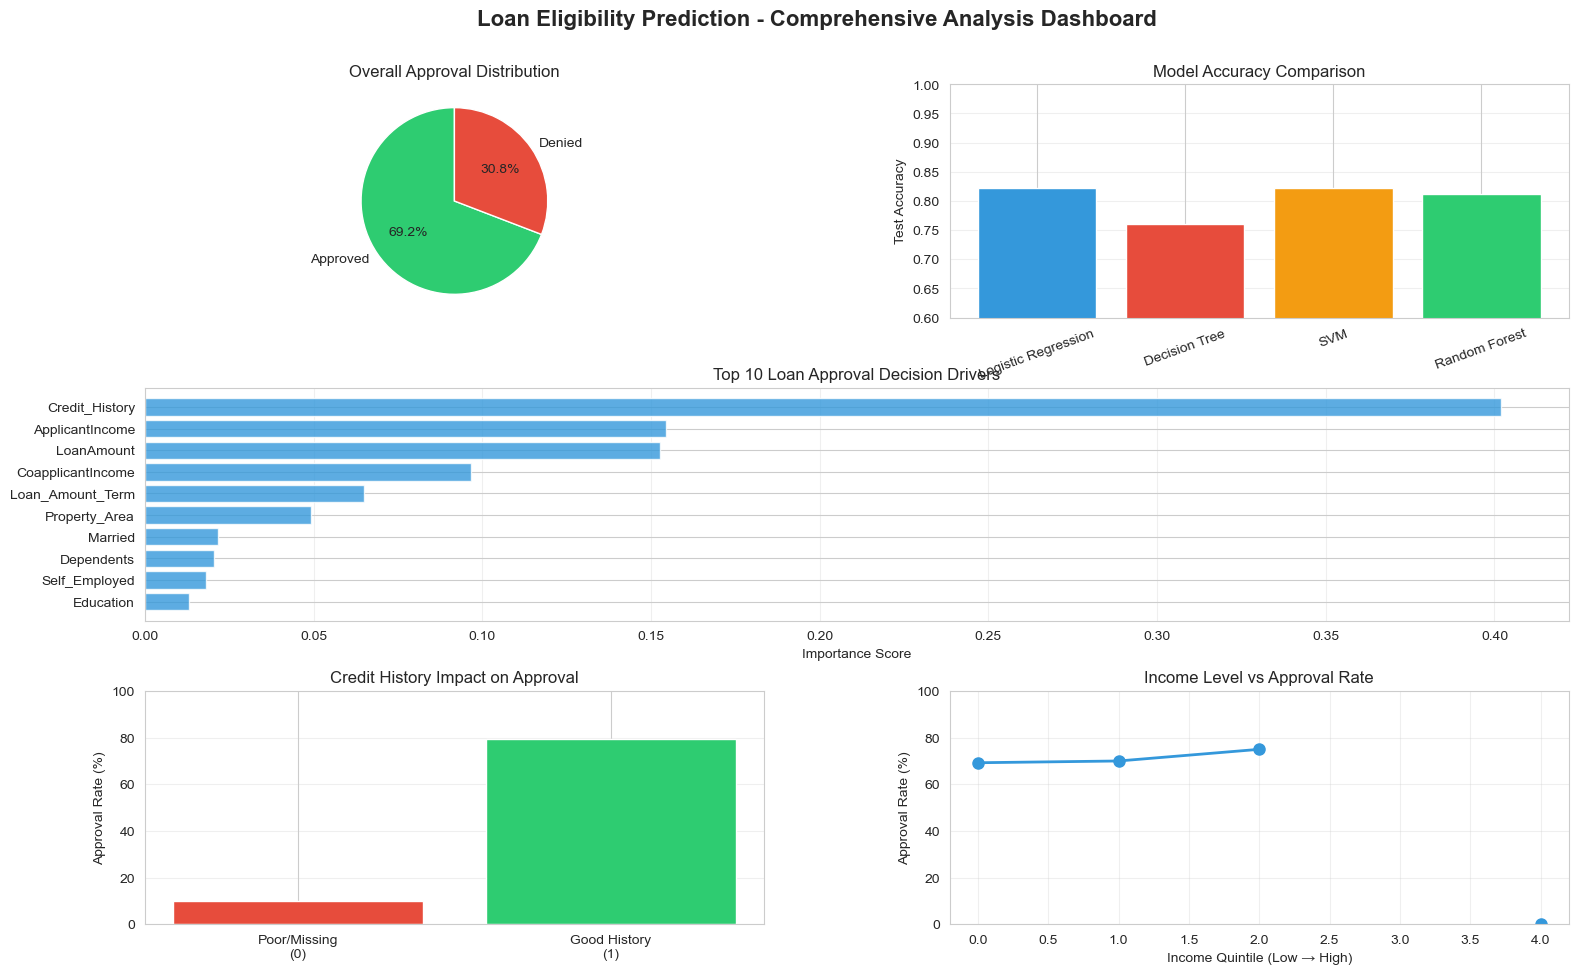

In [39]:
# Create a final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Approval Distribution
ax1 = fig.add_subplot(gs[0, 0])
approval_counts = df['Loan_Status'].value_counts()

ax1.pie(
    [approval_counts[1], approval_counts[0]],
    labels=['Approved', 'Denied'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
ax1.set_title('Overall Approval Distribution')

# 2. Model Accuracy
ax2 = fig.add_subplot(gs[0, 1])

ax2.bar(
    comparison_df['Model'],
    comparison_df['Test Accuracy'],
    color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
)

ax2.set_ylabel('Test Accuracy')
ax2.set_title('Model Accuracy Comparison')
ax2.set_ylim([0.6, 1.0])
ax2.tick_params(axis='x', rotation=20)
ax2.grid(axis='y', alpha=0.3)

# 3. Top Features
ax3 = fig.add_subplot(gs[1, :])

top_10 = combined_importance.head(10)

ax3.barh(
    range(len(top_10)),
    top_10['Avg_Importance'],
    color='#3498db',
    alpha=0.8
)

ax3.set_yticks(range(len(top_10)))
ax3.set_yticklabels(top_10['Feature'])
ax3.set_xlabel('Importance Score')
ax3.set_title('Top 10 Loan Approval Decision Drivers')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Credit History Impact
ax4 = fig.add_subplot(gs[2, 0])

credit_approval = df.groupby('Credit_History')['Loan_Status'].agg(['sum', 'count'])
credit_approval['rate'] = (
    credit_approval['sum'] / credit_approval['count'] * 100
)

ax4.bar(
    ['Poor/Missing\n(0)', 'Good History\n(1)'],
    credit_approval['rate'],
    color=['#e74c3c', '#2ecc71']
)

ax4.set_ylabel('Approval Rate (%)')
ax4.set_title('Credit History Impact on Approval')
ax4.set_ylim([0, 100])
ax4.grid(axis='y', alpha=0.3)

# 5. Income vs Approval
ax5 = fig.add_subplot(gs[2, 1])

income_bins = pd.cut(df['ApplicantIncome'], bins=5)

income_approval = df.groupby(
    income_bins,
    observed=False
)['Loan_Status'].agg(['sum', 'count'])

income_approval['rate'] = (
    income_approval['sum'] / income_approval['count'] * 100
)

ax5.plot(
    range(len(income_approval)),
    income_approval['rate'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='#3498db'
)

ax5.set_ylabel('Approval Rate (%)')
ax5.set_xlabel('Income Quintile (Low → High)')
ax5.set_title('Income Level vs Approval Rate')
ax5.set_ylim([0, 100])
ax5.grid(alpha=0.3)

plt.suptitle(
    'Loan Eligibility Prediction - Comprehensive Analysis Dashboard',
    fontsize=16,
    fontweight='bold',
    y=0.995
)

plt.subplots_adjust(
    top=0.92,
    bottom=0.08,
    left=0.08,
    right=0.97,
    hspace=0.45,
    wspace=0.35
)
plt.show()

# LOAN PREDICTION: Decision Tree, SVM and  Logistic Regression

In [41]:
import pandas as pd  
import numpy as np  
import seaborn as sns  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split  
from sklearn import tree  
from sklearn.tree import plot_tree  
from sklearn.metrics import accuracy_score 


## PART 1 - Data Handling

In [43]:
# Importing data with pandas
data = pd.read_csv("loan_dataset.csv")

In [44]:
# Showing an overview of our data
data 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [45]:
# The shape property returns a tuple representing the dimensionality of the DataFrame. 
# The format of shape is (rows, columns).
data.shape

(614, 13)

In [46]:
# Pandas describe() is used to view some basic statistical details like percentile, mean, std etc. of a data frame or a series of numeric values. W
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [47]:
# Taking care of missing values
# Within pandas, a null value is considered missing and is denoted by NaN.
# First, I need to find out the number of missing values in each column.
# To see how many missing values exist in the collection I use .sum() chained on the function isnull(). 
data.isnull().sum()  

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [48]:
# The dropna() function removes the empty fields from the data
data = data.dropna()  

In [49]:
# Checking whether any value is still missing
data.isnull().sum()  

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [50]:
print(data['Loan_Status'].unique())
print(data['Loan_Status'].head(10).tolist())
print(data['Loan_Status'].value_counts(dropna=False))
print(data['Loan_Status'].dtype)
print(data['Loan_Status'].unique())

['N' 'Y']
['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y']
Loan_Status
Y    332
N    148
Name: count, dtype: int64
object
['N' 'Y']


In [51]:
# With the replace method all Y values will be replaced with boolean values
# With the implance method the table will be changed here
data = data.copy()
data['Loan_Status'] = data['Loan_Status'].map({'N': 0, 'Y': 1})

In [52]:
import pandas as pd

# Read dataset
data = pd.read_csv("loan_dataset.csv")

# Remove missing values
data = data.dropna().copy()

# Convert target variable
data["Loan_Status"] = data["Loan_Status"].map({"N": 0, "Y": 1})

# Verify
print(data.shape)
print(data["Loan_Status"].value_counts())

(480, 13)
Loan_Status
1    332
0    148
Name: count, dtype: int64


In [53]:
print(data['Loan_Status'].head(10))
print(data['Loan_Status'].value_counts(dropna=False))

1     0
2     1
3     1
4     1
5     1
6     1
7     0
8     1
9     0
10    1
Name: Loan_Status, dtype: int64
Loan_Status
1    332
0    148
Name: count, dtype: int64


In [54]:
# Checking te table again
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [55]:
# Checking how many lines contains dependents  
data["Dependents"].value_counts()  

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [56]:
# We cannot have "+", so we fix this issue replacing "3+". I will call it " "4" 
data = data.replace(to_replace="3+",value=4)

In [57]:
# Now, I should count again
data["Dependents"].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

In [58]:
print(data.shape)
print(data["Loan_Status"].value_counts(dropna=False))
print(data["Loan_Status"].isna().sum())

(480, 13)
Loan_Status
1    332
0    148
Name: count, dtype: int64
0


<Axes: xlabel='Education', ylabel='count'>

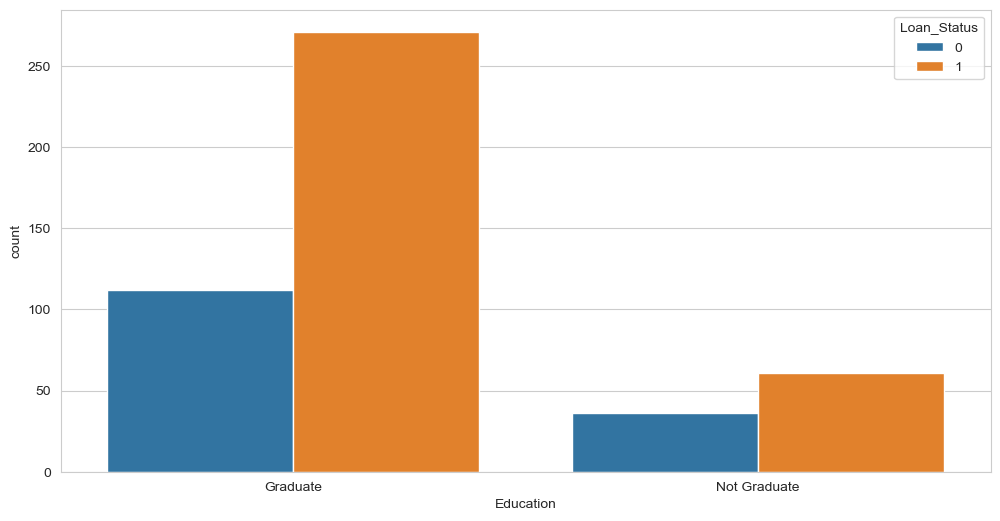

In [59]:
# Exploring Data through Visualizations with Seaborn
# Verifying if the Y is related to the level of education
sns.countplot(x="Education",hue="Loan_Status", data=data)  

<Axes: xlabel='Married', ylabel='count'>

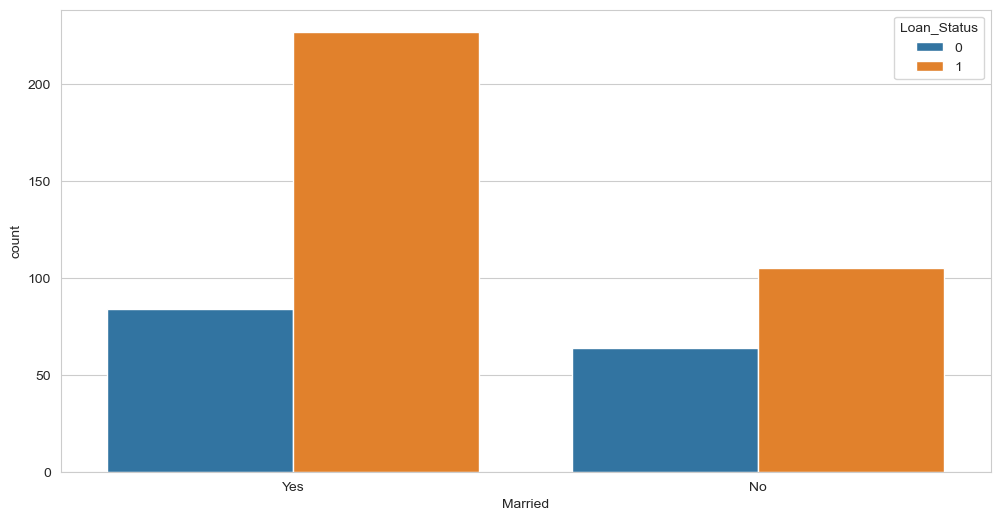

In [60]:
 # Checking if the y is related to marital status
sns.countplot(x="Married",hue="Loan_Status", data=data) 

<Axes: xlabel='Dependents', ylabel='count'>

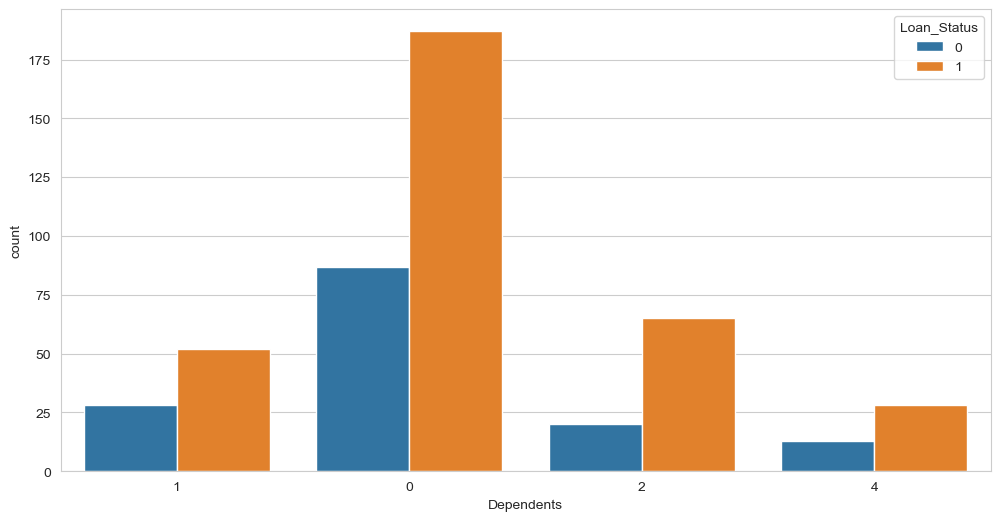

In [61]:
sns.countplot(x="Dependents",hue="Loan_Status",data=data)

In [62]:
data["Property_Area"].value_counts()

Property_Area
Semiurban    191
Urban        150
Rural        139
Name: count, dtype: int64

In [63]:
data = data.replace({
    "Married": {"No": 0, "Yes": 1},
    "Gender": {"Female": 0, "Male": 1},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Property_Area": {"Rural": 0, "Semiurban": 1, "Urban": 2},
    "Education": {"Not Graduate": 0, "Graduate": 1}
}).infer_objects(copy=False)

/var/folders/t1/z3pm4glx5ljflgqgmpkqdqkh0000gn/T/ipykernel_89619/3601052077.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({


In [64]:
# Checking how it looks 
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


## PART 2 - Data Analysis

In [66]:
# Defining X by removing Loan_ID and Loan_Status (which is Y)
X  = data.drop(columns=["Loan_ID","Loan_Status"],axis=1)
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
610,1,1,4,1,0,4106,0.0,40.0,180.0,1.0,0
611,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,2
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,2


In [67]:
# Y will be defined as Loan_Status
Y = data["Loan_Status"]
Y

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64

In [68]:
 # Separating data into training and testing sets
train_test_split(X,Y,test_size=0.2) # wih the third parameter being the test_size, it automatically recognizes the training as 80%
 

[     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
 413       1        1          0          0              0             2253   
 243       1        1          2          1              1             6250   
 128       1        1          1          1              1            10513   
 375       1        1          0          1              0             4817   
 359       1        1          4          1              0             5167   
 ..      ...      ...        ...        ...            ...              ...   
 51        0        0          0          1              0             3086   
 598       1        1          0          1              1             9963   
 262       0        0          1          1              0             3481   
 291       1        1          2          1              0             4400   
 438       1        0          0          1              1            10416   
 
      CoapplicantIncome  LoanAmount  Loan_Amount_T

In [69]:
# We have the data above in the following order: x training / x test / y training / y teste
# Now I store this in 4 variables:
X_train,X_test,Y_train,Y_real=train_test_split(X,Y,test_size=0.2)

In [70]:
# Check the size of X training and x test
X_train.shape 

(384, 11)

In [71]:
X_test.shape 

(96, 11)

## Decision Tree Model 

In [73]:
# Creating the model  
model = tree.DecisionTreeClassifier(max_depth=3) 
model

DecisionTreeClassifier(max_depth=3)

In [74]:
# Passing our training set to the fit method 
# In fit we fit\train the weights using the training data. Note: Before you can make predictions, you must train a final model.
model.fit(X_train,Y_train) 

DecisionTreeClassifier(max_depth=3)

In [75]:
# Making a prediction to test the training 
model.predict(X_test) # It receives X as a parameter to predict Y  

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [76]:
# Storing the result in a variable 
Y_pred = model.predict(X_test)

In [77]:
# Checking model accuracy
accuracy_score(Y_pred,Y_real)
 

0.7708333333333334

In [78]:
# Getting the columns names
X.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

[Text(0.4583333333333333, 0.875, 'Credit_History <= 0.5\ngini = 0.428\nsamples = 384\nvalue = [119, 265]\nclass = Accepted'),
 Text(0.25, 0.625, 'LoanAmount <= 547.5\ngini = 0.188\nsamples = 57\nvalue = [51, 6]\nclass = Denied'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'CoapplicantIncome <= 6981.5\ngini = 0.163\nsamples = 56\nvalue = [51, 5]\nclass = Denied'),
 Text(0.08333333333333333, 0.125, 'gini = 0.137\nsamples = 54\nvalue = [50, 4]\nclass = Denied'),
 Text(0.25, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Denied'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Accepted'),
 Text(0.6666666666666666, 0.625, 'LoanAmount <= 285.0\ngini = 0.329\nsamples = 327\nvalue = [68, 259]\nclass = Accepted'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'Loan_Amount_Term <= 420.0\ngini = 0.308\nsamples = 310\nvalue = [59.0, 251.0]\nclass = Accepted'),
 Text(0.4166666666666667, 0.125, 'gini = 0.296\nsample

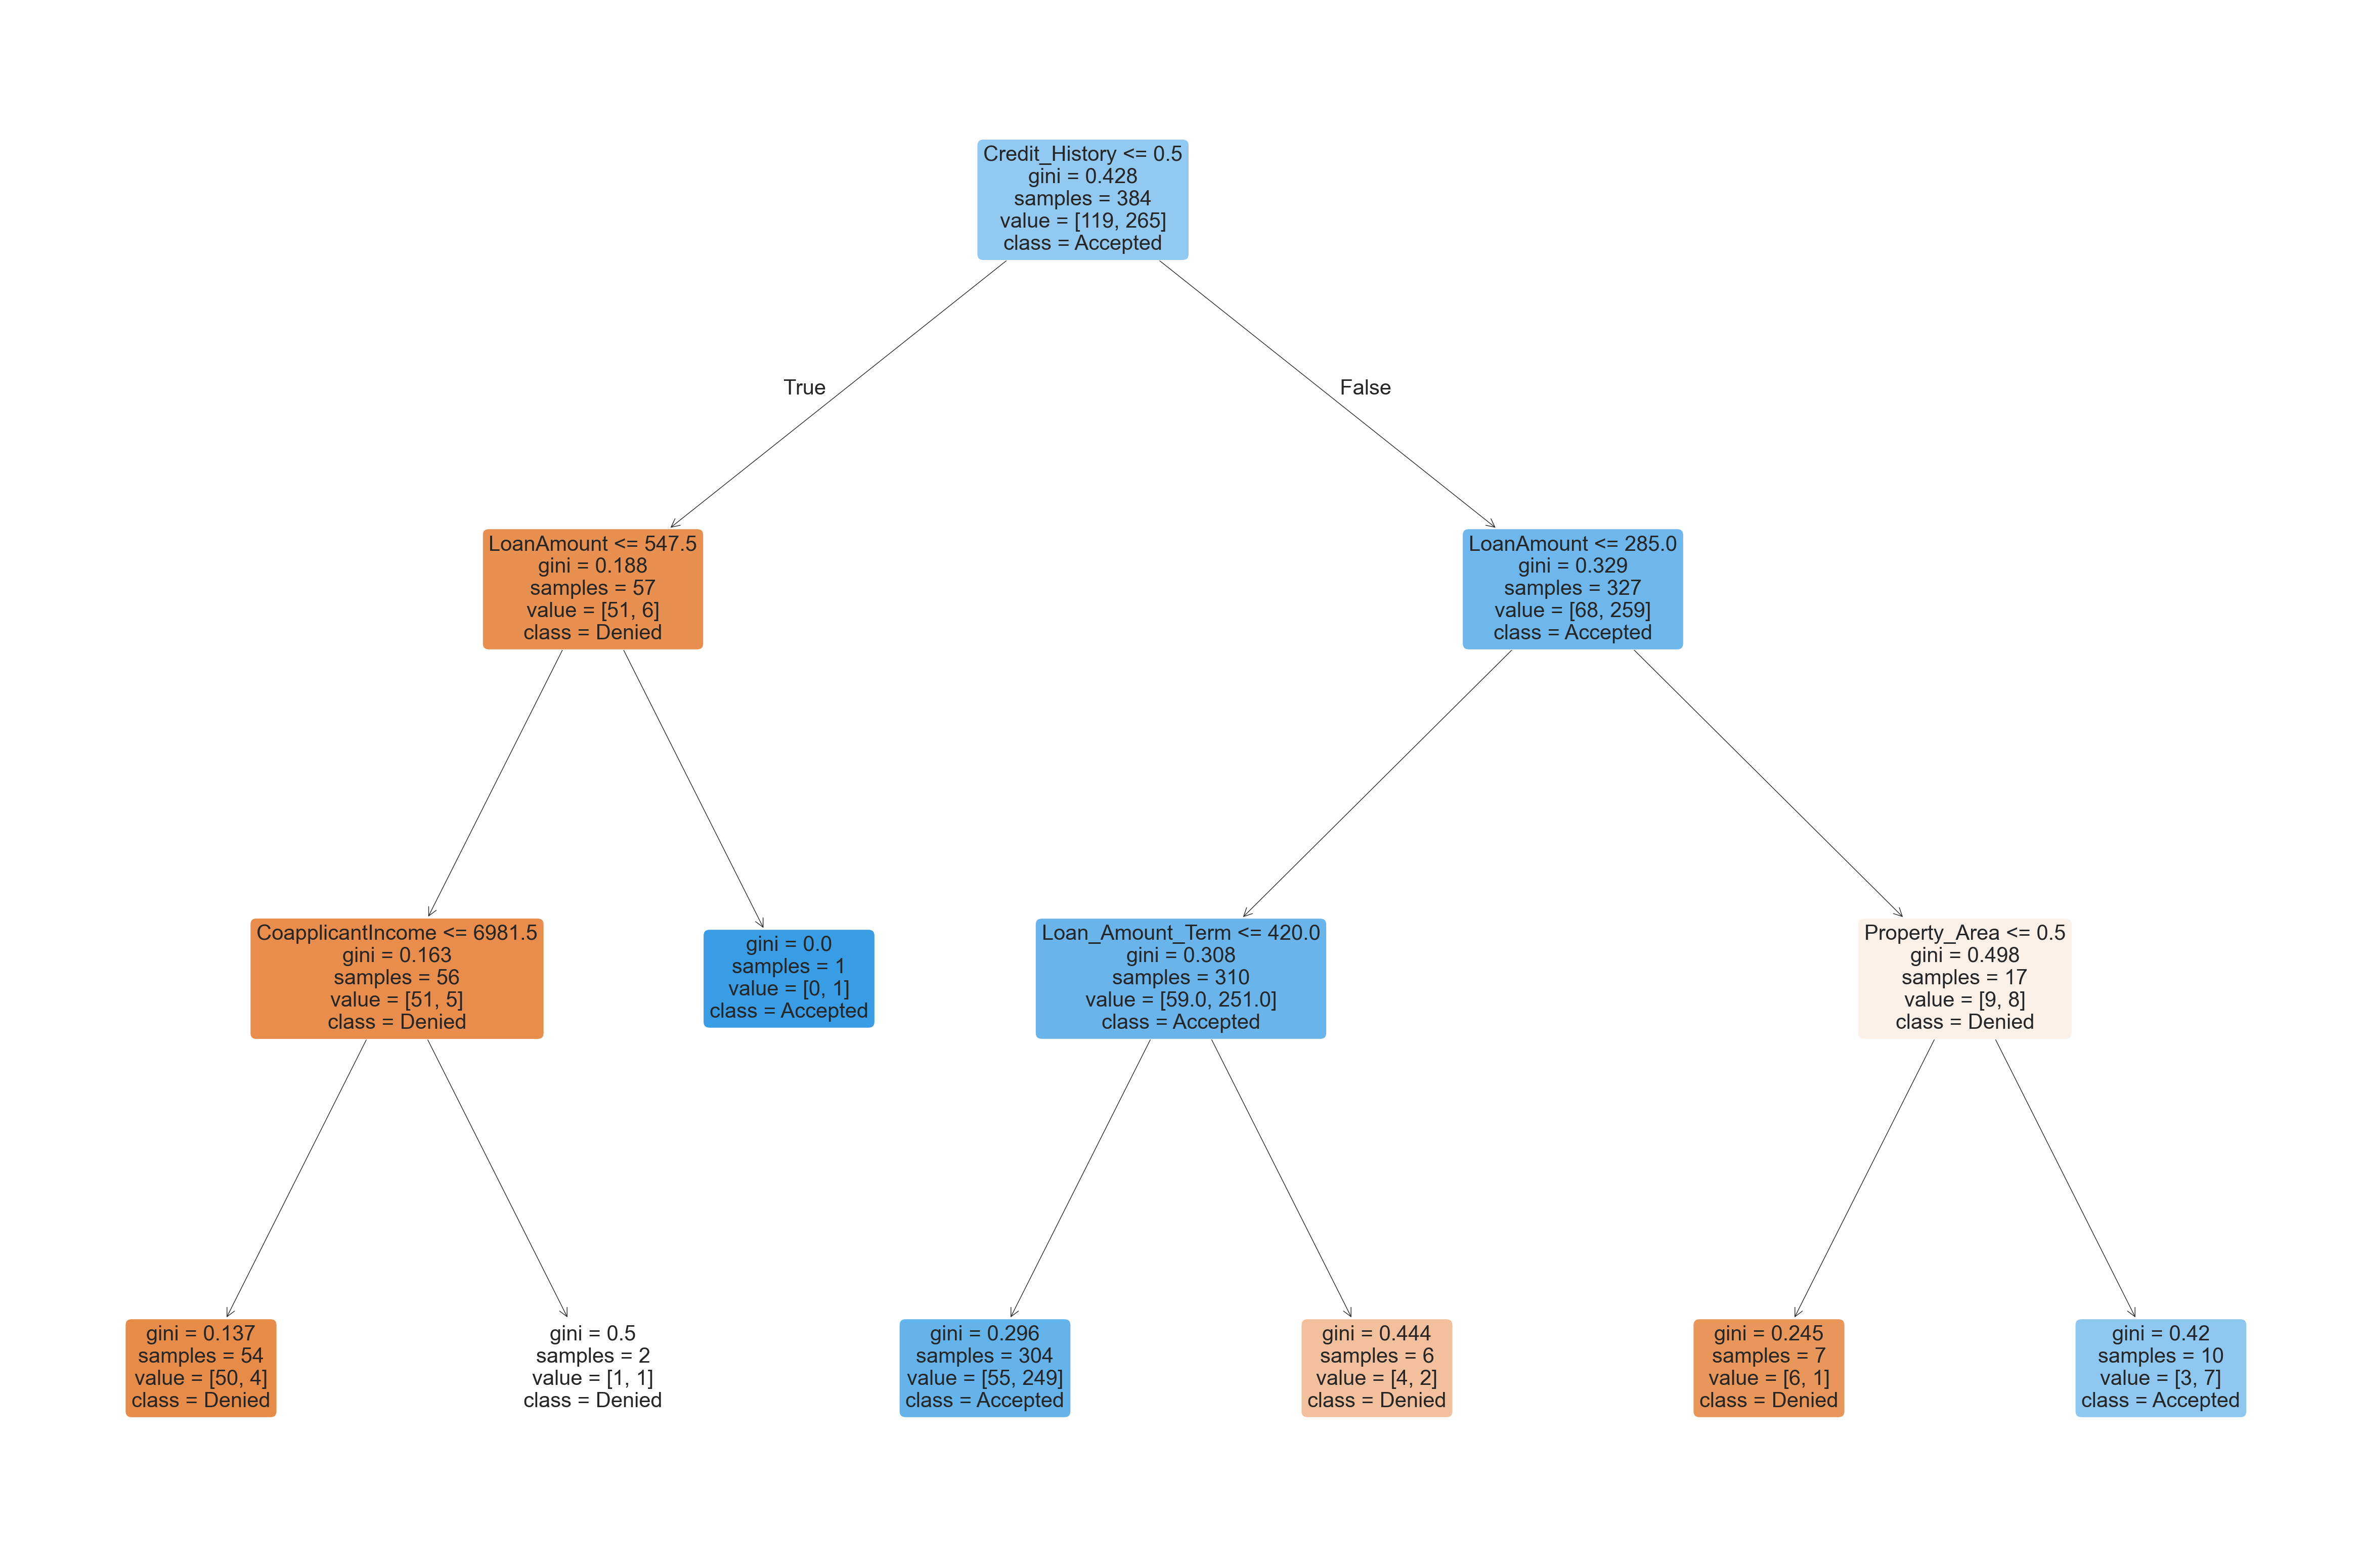

In [79]:
# Creating the tree with the plot tree function
# Use the figsize of plt.figure to control the size of the rendering 
plt.figure(figsize=(60,40))
plot_tree(model,
         feature_names = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
          class_names = ["Denied","Accepted"], filled=True, rounded=True, fontsize=30)

## Suport Vector Machine (SVC)

In [81]:
from sklearn import svm 
model_SVC = svm.SVC(kernel="linear") # defining the method. I tested poli and rff but linear had the best accuracy (poli = 0,6875 /rff = 0,6875 )
model_SVC

SVC(kernel='linear')

In [82]:
model_SVC.fit(X_train,Y_train)

SVC(kernel='linear')

In [83]:
# Testing
Y_pred = model_SVC.predict(X_test)
Y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [84]:
# Comparing the predicted y with the real y find the accuracy
accuracy_score(Y_pred,Y_real)

0.8020833333333334

## Logistic Regression

In [86]:
from sklearn.linear_model import LogisticRegression
 

In [87]:
# For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones.
log_reg = LogisticRegression(solver = 'liblinear')

In [88]:
#training the model 
log_reg.fit(X_train,Y_train)

LogisticRegression(solver='liblinear')

In [89]:
#salvando o teste do modelo numa variável 
y_pred = log_reg.predict(X_test)

In [90]:
y_pred #note the large amount of zeros. Means that the models is predicting more situations where the result is False. Note q por isso o modelo ficará mais biased para rejeitar do que aceitar  

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [91]:
 
# Accuracy = true negatives + true positives / true positives + false positives + true negatives + false negatives
acc = accuracy_score(Y_real,y_pred)  
acc

0.8125

## PART 3 - Valuation Analysis: using kfold, a model validation technique

### Performance Measurement (accuracy score) 

In [94]:
# I have found the accuracy score for the Decision Tree model (line 130) and SVM model (line 136). 
# Here are the results: 

# -> Decision Tree model  - accuracy score:  0.84375
# -> SVM model - accuracy score:  0.78125
# -> Logistic Regression model - accuracy score: 0.84375

### Kfold -> Decision Tree

In [96]:
# Now using kfold, a model validation technique where it's not using your pre-trained model
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=5,shuffle=True)  
cv_r = cross_val_score(model, X, Y, cv=kf)
np.mean(cv_r)

0.7854166666666667

### Kfold -> Support Vector Machine

In [99]:
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

In [100]:
kf_svm = KFold(n_splits=5,shuffle=True)  
# first parameter = Number of folds. Must be at least 2.
# second parameter = Whether to shuffle the data before splitting into batches.

In [101]:
# Evaluating a score by cross-validation  
cv_svm = cross_val_score(model_SVC, X, Y, cv=kf_svm)  
# first parameter = The object to use to fit the data.
# second parameter = X
# second parameter = Y
# third parameter = cross validation
# NOTE: it took the empty model, trained it, tested it and compared the test result (predicted y) with the real y.
# after making this comparison it returns the accuracy of each fold (5)
cv_svm

array([0.77083333, 0.79166667, 0.76041667, 0.84375   , 0.80208333])

In [102]:
# Mean accuracy 
np.mean(cv_svm)

0.79375

### Kfold -> Logistic Regression

In [104]:
kf_lg = KFold(n_splits=5,shuffle=True)

In [ ]:
cv_lg = cross_val_score(model_SVC, X, Y, cv=kf_lg)  

In [ ]:
# Mean accuracy 
np.mean(cv_lg)